# Data Exploration

In [5]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.data import load_all_data, prepare_sequences

sns.set_style('whitegrid')
%matplotlib inline

## Load Data

In [6]:
%load_ext autoreload
%autoreload 2

In [7]:
jobs, x_train, y_train, x_test = load_all_data()

print(f"Jobs: {len(jobs)}")
print(f"Train sessions: {len(x_train)}")
print(f"Test sessions: {len(x_test)}")

Jobs: 21917
Train sessions: 15882
Test sessions: 1819


In [8]:
x_train.head()

,session_id,job_ids,actions
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","['view', 'view', 'view', 'view', 'view', 'view..."
1,1,"[84, 257, 252, 250]","['view', 'view', 'view', 'view']"
2,2,"[241, 237, 221, 309, 310, 306, 301]","['view', 'view', 'apply', 'apply', 'apply', 'a..."
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","['apply', 'apply', 'apply', 'apply', 'apply', ..."
4,4,"[171, 291, 289, 166, 288, 155]","['apply', 'apply', 'apply', 'apply', 'apply', ..."


In [9]:
y_train.head()

,session_id,job_id,action
0,0,84,view
1,1,241,view
2,2,303,apply
3,3,171,apply
4,4,286,apply


## Prepare Sequences

In [10]:
x_train = prepare_sequences(x_train)
x_test = prepare_sequences(x_test)

## Session Length Analysis

In [11]:
x_train['seq_length'].describe()

count    15882.000000
mean         7.539793
std          3.577731
min          3.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         15.000000
Name: seq_length, dtype: float64

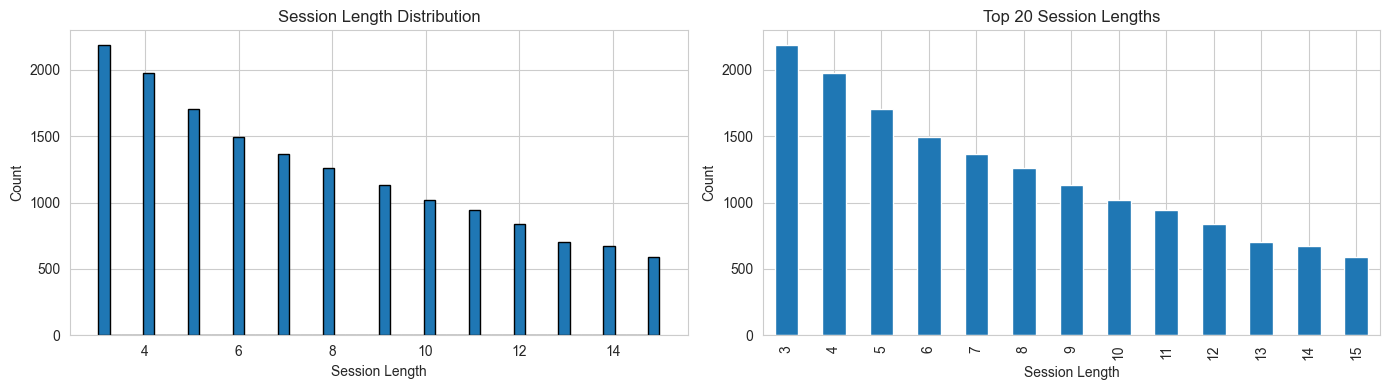

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(x_train['seq_length'], bins=50, edgecolor='black')
axes[0].set_xlabel('Session Length')
axes[0].set_ylabel('Count')
axes[0].set_title('Session Length Distribution')

x_train['seq_length'].value_counts().head(20).sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Session Length')
axes[1].set_ylabel('Count')
axes[1].set_title('Top 20 Session Lengths')

plt.tight_layout()
plt.show()

## Job Popularity

In [13]:
all_jobs = []
for jobs_list in x_train['jobs_list']:
    all_jobs.extend(jobs_list)

job_counts = Counter(all_jobs)

print(f"Unique jobs: {len(job_counts)}")
print(f"Total views: {len(all_jobs)}")
print(f"\nTop 10 most viewed:")
for job_id, count in job_counts.most_common(10):
    print(f"  Job {job_id}: {count} views")

Unique jobs: 20505
Total views: 119747

Top 10 most viewed:
  Job 518: 176 views
  Job 50: 164 views
  Job 302: 163 views
  Job 41: 159 views
  Job 2975: 152 views
  Job 1460: 152 views
  Job 88: 144 views
  Job 85: 143 views
  Job 3736: 142 views
  Job 1620: 142 views


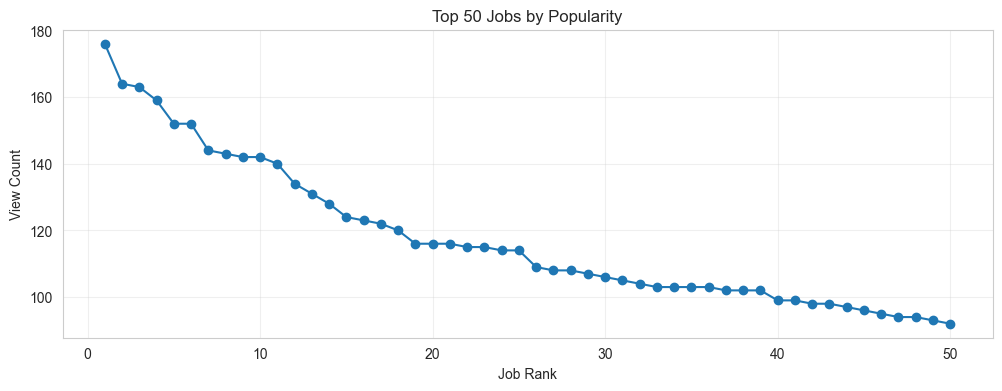

In [14]:
top_jobs = pd.Series([count for _, count in job_counts.most_common(50)])

plt.figure(figsize=(12, 4))
plt.plot(range(1, 51), top_jobs.values, marker='o')
plt.xlabel('Job Rank')
plt.ylabel('View Count')
plt.title('Top 50 Jobs by Popularity')
plt.grid(True, alpha=0.3)
plt.show()

## Action Distribution

In [15]:
all_actions = []
for actions_list in x_train['actions_list']:
    all_actions.extend(actions_list)

action_counts = Counter(all_actions)
print("Actions in sequences:")
for action, count in action_counts.items():
    print(f"  {action}: {count} ({count/len(all_actions)*100:.1f}%)")

Actions in sequences:
  view: 76115 (63.6%)
  apply: 43632 (36.4%)


In [16]:
print("\nTarget actions (next action):")
print(y_train['action'].value_counts())
print("\nPercentages:")
print(y_train['action'].value_counts(normalize=True) * 100)


Target actions (next action):
action
view     9608
apply    6274
Name: count, dtype: int64

Percentages:
action
view     60.496159
apply    39.503841
Name: proportion, dtype: float64


## Target Jobs Analysis

In [17]:
target_job_counts = Counter(y_train['job_id'])

print(f"Unique target jobs: {len(target_job_counts)}")
print(f"\nTop 10 target jobs:")
for job_id, count in target_job_counts.most_common(10):
    print(f"  Job {job_id}: {count} times")

Unique target jobs: 7030

Top 10 target jobs:
  Job 518: 28 times
  Job 41: 28 times
  Job 1620: 26 times
  Job 1460: 24 times
  Job 155: 24 times
  Job 89: 23 times
  Job 50: 23 times
  Job 332: 22 times
  Job 85: 22 times
  Job 66: 21 times


## Job Listings DataFrame - Structured View

In [31]:
# Display first few jobs (without full_text for readability)
print("\n" + "="*50)
print("SAMPLE JOBS (First 10)")
print("="*50)
jobs_df.drop('full_text', axis=1).head(10)


SAMPLE JOBS (First 10)


,job_id,title,text_length,has_skills,has_tasks,has_languages,has_certifications,has_summary,has_description,num_sections
0,0,QA Intégration / Data Analyst - SalesForces S...,2851,True,True,True,True,True,True,8
1,1,Ingénieur Système,6204,True,True,True,True,True,True,8
2,2,Testeur QA Automatisation Cypress,3476,True,True,True,True,True,True,8
3,3,Ingénieur support N3 IP - PARIS,3023,True,True,True,True,True,True,8
4,4,Business Analyst MOA FRONT,4798,True,True,True,True,True,True,8
5,5,Business Analyst SAP S/4,3928,True,True,True,True,True,True,8
6,6,Salesforce Marketing Cloud Product Owner,7658,True,True,True,True,True,True,8
7,7,Responsable Sécurité Opérationnel,9152,True,True,True,True,True,True,8
8,8,Architecte d'entreprise Data BI,6025,True,True,True,True,True,True,8
9,9,Ingénieur.e QA web / mobile - (Haute-Savoie -...,2612,True,True,True,True,True,True,8


In [32]:
# Summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)

print(f"\nJobs with Skills: {jobs_df['has_skills'].sum()} ({jobs_df['has_skills'].mean()*100:.1f}%)")
print(f"Jobs with Tasks: {jobs_df['has_tasks'].sum()} ({jobs_df['has_tasks'].mean()*100:.1f}%)")
print(f"Jobs with Languages: {jobs_df['has_languages'].sum()} ({jobs_df['has_languages'].mean()*100:.1f}%)")
print(f"Jobs with Certifications: {jobs_df['has_certifications'].sum()} ({jobs_df['has_certifications'].mean()*100:.1f}%)")
print(f"Jobs with Summary: {jobs_df['has_summary'].sum()} ({jobs_df['has_summary'].mean()*100:.1f}%)")
print(f"Jobs with Description: {jobs_df['has_description'].sum()} ({jobs_df['has_description'].mean()*100:.1f}%)")

print("\nText length statistics:")
print(jobs_df['text_length'].describe())

print("\nNumber of sections statistics:")
print(jobs_df['num_sections'].value_counts().sort_index())


SUMMARY STATISTICS

Jobs with Skills: 21917 (100.0%)
Jobs with Tasks: 21917 (100.0%)
Jobs with Languages: 21917 (100.0%)
Jobs with Certifications: 21917 (100.0%)
Jobs with Summary: 21545 (98.3%)
Jobs with Description: 21916 (100.0%)

Text length statistics:
count    21917.000000
mean      3597.312953
std       1910.558423
min        242.000000
25%       2276.000000
50%       3222.000000
75%       4513.000000
max      35203.000000
Name: text_length, dtype: float64

Number of sections statistics:
num_sections
6        4
7      369
8    21544
Name: count, dtype: int64


In [33]:
# Search functionality example
print("\n" + "="*50)
print("SEARCH EXAMPLES")
print("="*50)

# Example 1: Find jobs with specific keyword in title
keyword = "Data"
matching_jobs = jobs_df[jobs_df['title'].str.contains(keyword, case=False, na=False)]
print(f"\nJobs with '{keyword}' in title: {len(matching_jobs)}")
print(matching_jobs[['job_id', 'title', 'has_skills', 'text_length']].head())

# Example 2: Find jobs with both skills and tasks
complete_jobs = jobs_df[(jobs_df['has_skills']) & (jobs_df['has_tasks'])]
print(f"\nJobs with both Skills and Tasks: {len(complete_jobs)}")
print(complete_jobs[['job_id', 'title', 'num_sections']].head())


SEARCH EXAMPLES

Jobs with 'Data' in title: 1807
   job_id                                              title  has_skills  \
0       0  QA Intégration / Data Analyst - SalesForces S...        True   
8       8                    Architecte d'entreprise Data BI        True   
41     41                               Data Scientist (H/F)        True   
49     49                                Data Engineer (H/F)        True   
91     91  Manager Réseau Sécurité Datacenter - Cloud ...        True   

    text_length  
0          2851  
8          6025  
41         7296  
49         3873  
91         6827  

Jobs with both Skills and Tasks: 21917
  job_id                                              title  num_sections
0      0  QA Intégration / Data Analyst - SalesForces S...             8
1      1                                Ingénieur Système             8
2      2                  Testeur QA Automatisation Cypress             8
3      3                   Ingénieur support N3 

In [ ]:
# Save DataFrame to CSV for easy access (optional)
print("\n" + "="*50)
print("SAVING STRUCTURED DATA")
print("="*50)

# Save without full_text to reduce file size
jobs_df_small = jobs_df.drop('full_text', axis=1)
jobs_df_small.to_csv('../Data/job_listings_structured.csv', index=False)
print("Saved structured job data to: Data/job_listings_structured.csv")

# Also save full version with text
jobs_df.to_csv('../Data/job_listings_full.csv', index=False)
print("Saved full job data to: Data/job_listings_full.csv")

print("\nNow you can easily:")
print("- Filter jobs by attributes")
print("- Sort by text length or sections")
print("- Search by keywords in titles")
print("- Join with training data using job_id")

In [4]:
import json
import pandas as pd
import os

# --- 1. CARGA DE DATOS ---
file_path = '../Data/job_listings.json'

try:
    with open(file_path, 'r', encoding='utf-8') as f:
        job_listings = json.load(f)
    print(f"✅ Archivo cargado correctamente. Total de ofertas: {len(job_listings)}")
except FileNotFoundError:
    print(f"❌ Error: No se encuentra el archivo en {file_path}")
    job_listings = {}

# --- 2. FUNCIÓN DE EXTRACCIÓN (GENÉRICA) ---
def parse_job_listing_content(job_id, job_text):
    """
    Extrae el texto completo de cada sección disponible.
    """
    # Lista de secciones posibles en tus archivos
    sections = ["TITLE", "SUMMARY", "DESCRIPTION", "SKILLS", "TASKS", "LANGUAGES", "CERTIFICATIONS", "COURSES"]
    
    parsed_data = {'job_id': job_id}
    
    # Extraer Título (Lógica específica porque suele estar al inicio)
    if "TITLE\n" in job_text:
        try:
            title_part = job_text.split("TITLE\n")[1]
            parsed_data['title'] = title_part.split("\n")[0].strip()
        except IndexError:
            parsed_data['title'] = ""
    
    # Extraer Contenido de Secciones Dinámicamente
    # 1. Buscamos dónde empieza cada sección
    section_indices = []
    for section in sections:
        header = section + "\n"
        idx = job_text.find(header)
        if idx != -1:
            section_indices.append((idx, section))
    
    # 2. Ordenamos por orden de aparición en el texto
    section_indices.sort(key=lambda x: x[0])
    
    # 3. Recortamos el texto entre una sección y la siguiente
    for i, (start_idx, section_name) in enumerate(section_indices):
        content_start = start_idx + len(section_name) + 1 
        
        # El final es el inicio de la siguiente sección o el final del archivo
        if i < len(section_indices) - 1:
            content_end = section_indices[i+1][0]
        else:
            content_end = len(job_text)
            
        # Guardamos el contenido limpio en una columna llamada 'nombreseccion_content'
        # Ej: skills_content, tasks_content
        parsed_data[f'{section_name.lower()}_content'] = job_text[content_start:content_end].strip()

    parsed_data['text_length'] = len(job_text)
    return parsed_data

# --- 3. CREACIÓN DEL DATAFRAME ---
if job_listings:
    print("Procesando ofertas...")
    job_data = [parse_job_listing_content(id, text) for id, text in job_listings.items()]
    jobs_df = pd.DataFrame(job_data)

    print(f"DataFrame creado con dimensión: {jobs_df.shape}")
    print("\nColumnas generadas con la data real:")
    print(jobs_df.columns.tolist())

    # --- 4. VISUALIZACIÓN DE LA DATA (SKILLS) ---
    # Ajustamos pandas para ver el texto completo de la celda
    pd.set_option('display.max_colwidth', 100)
    
    print("\n--- Ejemplo de contenido real en 'skills_content' ---")
    if 'skills_content' in jobs_df.columns:
        # Mostramos solo las que no son nulas para ver datos reales
        print(jobs_df[['title', 'skills_content']].dropna().head())
    else:
        print("No se encontraron skills en estas ofertas.")

✅ Archivo cargado correctamente. Total de ofertas: 21917
Procesando ofertas...
DataFrame creado con dimensión: (21917, 11)

Columnas generadas con la data real:
['job_id', 'title', 'title_content', 'summary_content', 'languages_content', 'certifications_content', 'skills_content', 'courses_content', 'tasks_content', 'text_length', 'description_content']

--- Ejemplo de contenido real en 'skills_content' ---
                                                      title  \
0  QA Intégration / Data Analyst - SalesForces Sales Cloud   
1                                       Ingénieur Système   
2                         Testeur QA Automatisation Cypress   
3                          Ingénieur support N3 IP - PARIS   
4                                Business Analyst MOA FRONT   

                                                                                        skills_content  
0                                  - {'name': 'Salesforce Sales Cloud', 'type': 'hard', 'value': None}  


In [5]:
# Ver las primeras 5 filas de la tabla principal
jobs_df.head()

,job_id,title,title_content,summary_content,languages_content,certifications_content,skills_content,courses_content,tasks_content,text_length,description_content
0,0,QA Intégration / Data Analyst - SalesForces Sales Cloud,QA Intégration / Data Analyst - SalesForces Sales Cloud,Responsabilités :\nAssurer la qualité des données intégrées entre Salesforce et d'autres sy...,,,"- {'name': 'Salesforce Sales Cloud', 'type': 'hard', 'value': None}",,"- {'name': 'assurer la qualité des données intégrées', 'value': None}\n- {'name': 'collabore...",2851,NaN
1,1,Ingénieur Système,Ingénieur Système,Nous recherchons un Ingénieur Système pour notre client. Le candidat idéal devra posséder de...,,,"- {'name': 'Administration linux', 'type': 'hard', 'value': None}\n- {'name': 'Administration Wi...",,"- {'name': 'administrer des serveurs middleware', 'value': None}\n- {'name': 'administrer et mai...",6204,NaN
2,2,Testeur QA Automatisation Cypress,Testeur QA Automatisation Cypress,Vous avez au moins une première expérience sur l’automatisation de tests\nLa connaissance de J...,,,"- {'name': 'Cypress', 'type': 'hard', 'value': None}\n- {'name': 'Jenkins', 'type': 'hard', 'val...",,"- {'name': 'approche axée sur les solutions', 'value': None}\n- {'name': 'assister les utilisat...",3476,NaN
3,3,Ingénieur support N3 IP - PARIS,Ingénieur support N3 IP - PARIS,Dans le cadre de cette mission :\nVous garantissez le support technique N3 afin d'accroître la ...,,,"- {'name': 'Adressage IP', 'type': 'hard', 'value': None}\n- {'name': 'BGP (Border Gateway Proto...",,"- {'name': 'apporter un support technique sur le fonctionnement des équipements', 'value': None...",3023,NaN
4,4,Business Analyst MOA FRONT,Business Analyst MOA FRONT,Nous recherchons un (e) consultant(e) ayant une expérience de minimum 4 ans en MOA et gestion d...,,,"- {'name': 'autonomie', 'type': 'hard', 'value': None}\n- {'name': 'Relation client', 'type': 'h...",,"- {'name': 'accompagnement de la maitrise d’œuvre sur la réalisation des besoins', 'value': Non...",4798,NaN


In [6]:
import ast

# Función para limpiar el texto y convertirlo en datos reales
def process_skills_column(text):
    if pd.isna(text) or text == '':
        return []
    skills_found = []
    # Dividimos por salto de línea porque cada skill está en una línea nueva con un guion
    for line in text.split('\n'):
        line = line.strip()
        if line.startswith('- '):
            # Quitamos el guion "- " y convertimos el texto a diccionario
            dict_text = line[2:]
            try:
                skill_dict = ast.literal_eval(dict_text)
                skills_found.append(skill_dict)
            except:
                continue
    return skills_found

print("Generando tabla detallada de Skills...")

# 1. Extraemos todas las skills de todas las ofertas
all_skills_data = []

# Iteramos por el DataFrame original
for index, row in jobs_df.iterrows():
    skills_list = process_skills_column(row['skills_content'])
    
    for skill in skills_list:
        # Añadimos el ID de la oferta para no perder el rastro
        skill['job_id'] = row['job_id']
        all_skills_data.append(skill)

# 2. Creamos el DataFrame de Skills
skills_df = pd.DataFrame(all_skills_data)

# Reordenamos columnas para que sea más legible
if not skills_df.empty:
    skills_df = skills_df[['job_id', 'name', 'type', 'value']]

print(f"✅ Tabla de Skills creada con {len(skills_df)} filas.")
print("\n--- PRIMERAS FILAS DE LA TABLA DE SKILLS ---")
display(skills_df.head(10))

print("\n--- CONTEO POR TIPO DE SKILL ---")
print(skills_df['type'].value_counts())

Generando tabla detallada de Skills...
✅ Tabla de Skills creada con 147376 filas.

--- PRIMERAS FILAS DE LA TABLA DE SKILLS ---


,job_id,name,type,value
0,0,Salesforce Sales Cloud,hard,None
1,1,Administration linux,hard,None
2,1,Administration Windows,hard,None
3,1,Apache Tomcat,hard,None
4,1,Azure,hard,None
5,1,Azure DevOps Server,hard,None
6,1,DevOps,hard,None
7,1,Google Cloud Platform,hard,None
8,1,Virtualisation,hard,None
9,1,VMware,hard,None



--- CONTEO POR TIPO DE SKILL ---
type
hard    136780
soft     10596
Name: count, dtype: int64
